# Higher precision boundaries

In [6]:
# Import my custom code from the editable package in sitnikov/src
from src.integrator.integrate import *

#Import other libraries
import numpy as np
import matplotlib.pyplot as plt
import rebound
from scipy.optimize import brentq

In [8]:
def B2_tv_array(dv, N_t, e):
    z0 = (np.sqrt(2)/4 * e / dv)**(2/5)
    r_2 = 1/2* (1 + e)
    v2 = np.sqrt(2/np.sqrt(z0**2 + r_2**2))

    # We store the points in a list
    # First the inner boundary (B2) inside of which we have certain return
    B2_tv_arr = np.zeros((2, N_t))

    for (i,t) in zip(range(N_t), np.linspace(0, 2*np.pi, N_t, endpoint=False)):
        # We initialize with negative velocity at negative time to integrate backwards
        sim = initialize_simulation(e = e, z = z0, z_dot = -v2, t = -t)
        
        # Now we integrate until we have intersection with z = 0
        dt = 0.1 # Initial timestep where we look for intersection with z = 0

        sim_prev = sim.copy()
        sim.integrate(sim.t + dt)

        while sim.particles[2].z > 0:
            sim_prev = sim.copy()
            sim.integrate(sim.t + dt)

        # Now we have that the crossing occurs between sim_prev.t and sim.t,
        # so we refine with brentq    

        def z_func(t):
            sim_loc = sim_prev.copy()
            sim_loc.integrate(t, exact_finish_time=1)
            return sim_loc.particles[2].z
        
        t_cross = brentq(z_func, sim_prev.t, sim_prev.t + dt, xtol = 1e-14)

        sim_prev.integrate(t_cross)
        v_final = sim_prev.particles[2].vz

        # We change signs again to the final backwards-integrated values
        B2_tv_arr[1][i] = -v_final
        B2_tv_arr[0][i] = (-t_cross) % (2*np.pi)
    
    return B2_tv_arr

In [9]:
def B1_tv_array(dv, N_t, e):
    z0 = (np.sqrt(2)/4 * e / dv)**(2/5)
    r_1 = 1/2* (1 - e)
    v1 = np.sqrt(2/np.sqrt(z0**2 + r_1**2))

    # We store the points in a list
    # First the inner boundary (B2) inside of which we have certain return
    B1_tv_arr = np.zeros((2, N_t))

    for (i,t) in zip(range(N_t), np.linspace(0, 2*np.pi, N_t, endpoint=False)):
        # We initialize with negative velocity at negative time to integrate backwards
        sim = initialize_simulation(e = e, z = z0, z_dot = -v1, t = -t)
        
        # Now we integrate until we have intersection with z = 0
        dt = 0.1 # Initial timestep where we look for intersection with z = 0

        sim_prev = sim.copy()
        sim.integrate(sim.t + dt)

        while sim.particles[2].z > 0:
            sim_prev = sim.copy()
            sim.integrate(sim.t + dt)

        # Now we have that the crossing occurs between sim_prev.t and sim.t,
        # so we refine with brentq    

        def z_func(t):
            sim_loc = sim_prev.copy()
            sim_loc.integrate(t, exact_finish_time=1)
            return sim_loc.particles[2].z
        
        t_cross = brentq(z_func, sim_prev.t, sim_prev.t + dt, xtol = 1e-14)

        sim_prev.integrate(t_cross)
        v_final = sim_prev.particles[2].vz

        # We change signs again to the final backwards-integrated values
        B1_tv_arr[1][i] = -v_final
        B1_tv_arr[0][i] = (-t_cross) % (2*np.pi)
    
    return B1_tv_arr

## We test further values of dv, N_t, e

In [ ]:
dv = 1e-3
N_t = 100
e = 0.5

In [12]:
B2_tv = B2_tv_array(dv=dv, N_t=N_t, e=e)
B1_tv = B1_tv_array(dv=dv, N_t=N_t, e=e)

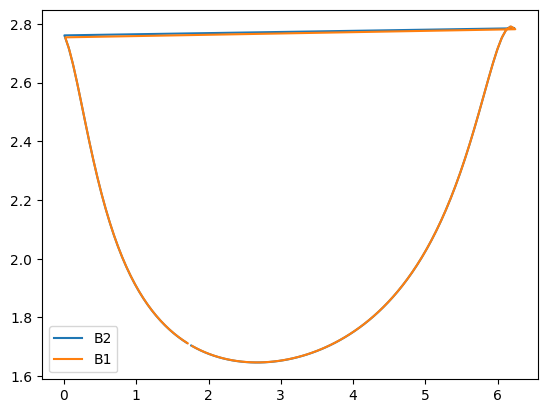

In [13]:
plt.plot(B2_tv[0], B2_tv[1], label = "B2")
plt.plot(B1_tv[0], B1_tv[1], label = "B1")

plt.legend()


The difference is now visually unnoticeable. To properly compare them we first need to interpolate the points obtained.

In [ ]:
from scipy.interpolate import CubicSpline
import numpy as np

def interpolate(t, tv_arr):
    '''
    Computes the interpolated value v(t) 
    given an array of samples tv_arr.
    tv_arr[0] is the array of t values (increasing with one wrap-around jump).
    tv_arr[1] is the array of v values.
    The function is 2pi periodic.
    '''
    t_samples = tv_arr[0]
    v_samples = tv_arr[1]
    
    # Handle wrap-around: find the jump where t decreases
    # Find the index where t[i+1] < t[i]
    diffs = np.diff(t_samples)
    jump_indices = np.where(diffs < 0)[0]
    
    if len(jump_indices) > 0:
        # We take the first jump found
        idx = jump_indices[0] + 1
        # Reorder arrays to be strictly increasing in t
        t_sorted = np.concatenate([t_samples[idx:], t_samples[:idx]])
        v_sorted = np.concatenate([v_samples[idx:], v_samples[:idx]])
    else:
        # Already sorted or all values are same (unlikely)
        t_sorted = t_samples
        v_sorted = v_samples
        
    # Close the periodic loop to ensure CubicSpline(bc_type = 'periodic') works
    t_closed = np.concatenate([t_sorted, np.array([t_sorted[0] + 2*np.pi])])
    v_closed = np.concatenate([v_sorted, np.array([v_sorted[0]])])
    
    # Create the periodic cubic spline
    cs = CubicSpline(t_closed, v_closed, bc_type='periodic')
    
    # Map input t to [0, 2pi] using modulo, though cs will handle periodicity if defined correctly
    return cs(t % (2 * np.pi))

In [18]:
t_vals = np.linspace(0, 2*np.pi, 20)
B1_v_vals = np.array([interpolate(t0, B1_tv) for t0 in t_vals])
B2_v_vals = np.array([interpolate(t0, B2_tv) for t0 in t_vals])

ValueError: `x` must be strictly increasing sequence.